# Step 1 — Understand the Business Problem
Objective

Segment customers into groups based on:

1. Purchasing behavior
2. Spending habits
3. Customer value

Using:

1. RFM Analysis
2. K-Means Clustering

# Step 2 — Define RFM

1. R - Recency

How recently a customer purchased.

2. F - Frequency

How often customer purchases.

3. M - Monetary

How much customer spends.

# Step 3. Importing Libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 4. Loading dataset

In [3]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# Step 5. Data cleaning 

In [4]:
# Remove missing values
df = df.dropna()



In [5]:
# Remove duplicates
df = df.drop_duplicates()

In [7]:
# Convert date column
df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer'],
    format='%d-%m-%Y'
)

In [8]:
# Create age column
df['Age'] = 2026 - df['Year_Birth']

In [10]:
# Remove unrealistic ages
df = df[df['Age'] < 100]

In [14]:
# Remove customers with zero purchases
df = df[df['Frequency'] > 0]

In [15]:
# Remove monetary outliers
df = df[df['Monetary'] < 2500]

In [16]:
# Reset index
df.reset_index(drop=True, inplace=True)

In [28]:
print(df.head())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  AcceptedCmp2  Complain  Z_CostContact  \
0  2012-09-04       58       635  ...             0         0              3   
1  2014-03-08       38        11  ...             0         0              3   
2  2013-08-21       26       426  ...             0         0              3   
3  2014-02-10       26        11  ...             0         0              3   
4  2014-01-19       94       173  ...             0         0              3   

   Z_Revenue  Response  Age  Frequency  Monetary  

# Step 6.  Create RFM Features


In [ ]:
# Creating Frequency
df['Frequency'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

In [18]:
# Create Monetary
df['Monetary'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

In [19]:
rfm = df[['Recency', 'Frequency', 'Monetary']]

rfm.head()

,Recency,Frequency,Monetary
0,58,22,1617
1,38,4,27
2,26,20,776
3,26,6,53
4,94,14,422


# Step 7. Scale data

In [20]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

# Step 8. Step 8 — Find Best Number of Clusters

Elbow Method

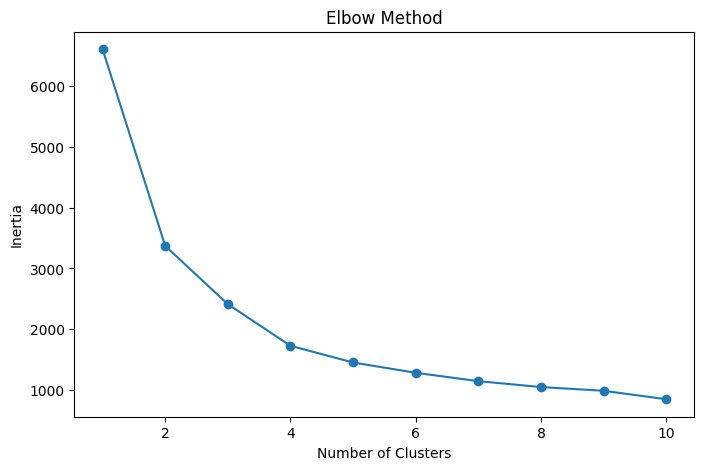

In [21]:
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Step 9. Apply K-means

In [22]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Step 10. Profile (Segment)

In [23]:
segment_profile = df.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean()

print(segment_profile)

           Recency  Frequency     Monetary
Cluster                                   
0        24.300163   6.781403   136.830343
1        73.193738  19.475538  1200.273973
2        74.418060   7.185619   152.494983
3        23.232365  19.371369  1135.506224


# Step 11. Cluster Plot 

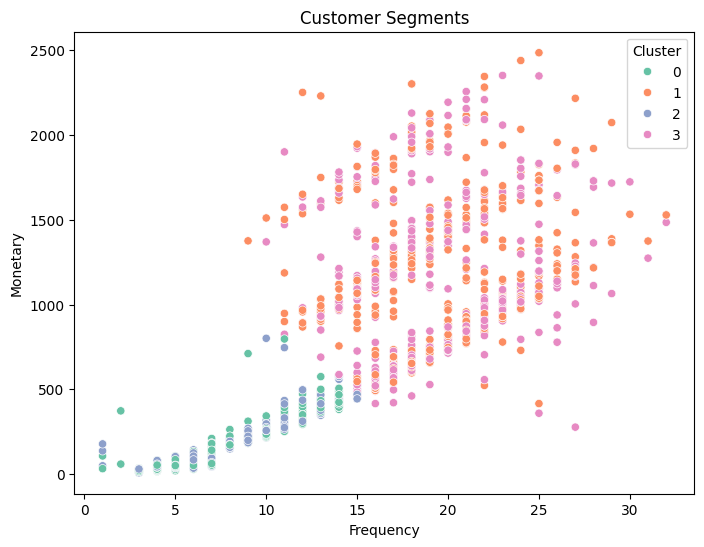

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    data=df,
    palette='Set2'
)

plt.title("Customer Segments")
plt.show()

In [25]:
print(df['Cluster'].value_counts())

Cluster
0    613
2    598
1    511
3    482
Name: count, dtype: int64


# Step 12. Segment Distribution

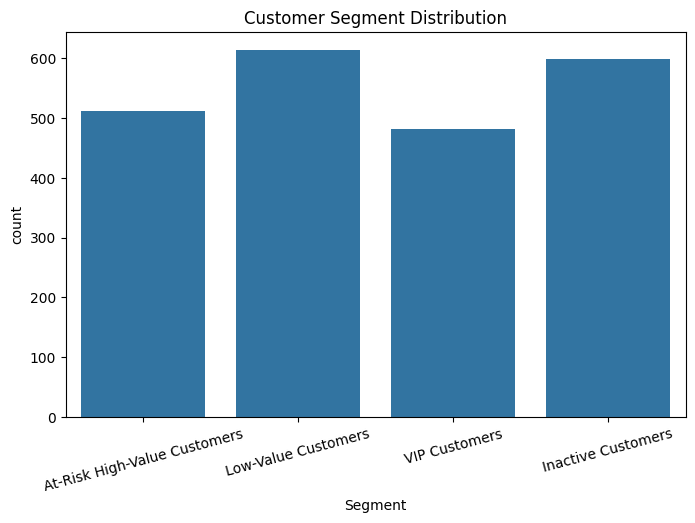

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Segment'
)

plt.xticks(rotation=15)

plt.title("Customer Segment Distribution")

plt.show()

# Step 13. Average Spending by Segment

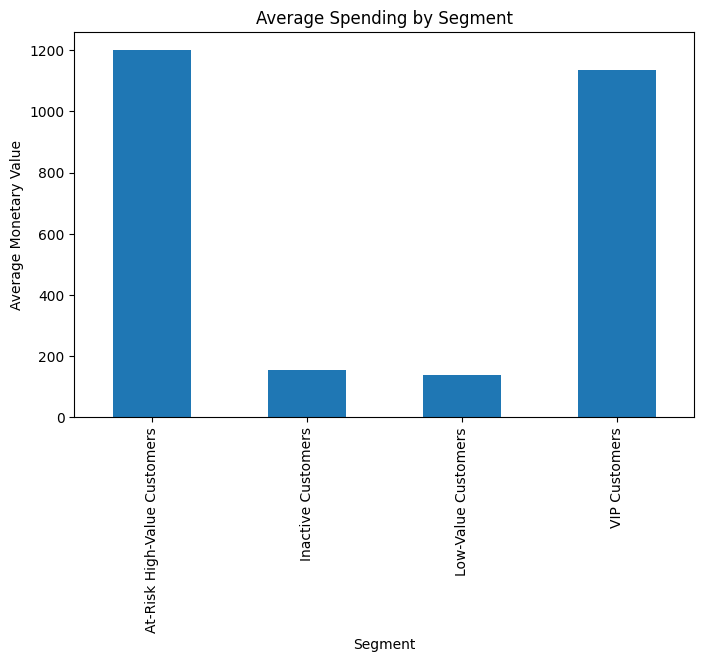

In [35]:
segment_spending = df.groupby('Segment')['Monetary'].mean()

segment_spending.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Spending by Segment")

plt.ylabel("Average Monetary Value")

plt.show()

# Step 14. Recency by Segment

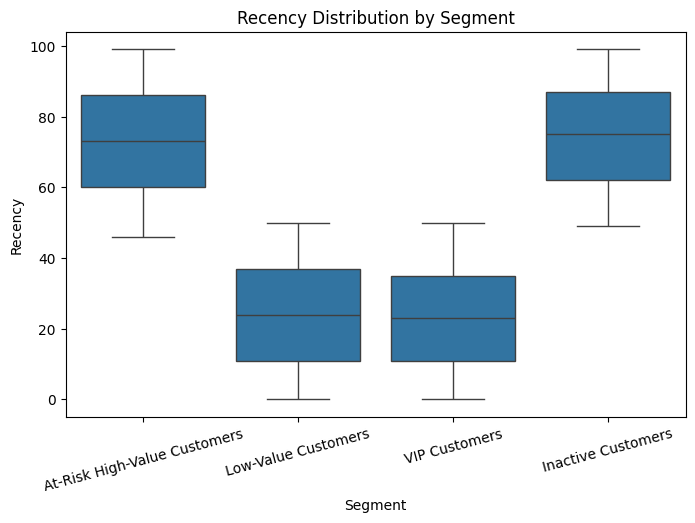

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Segment',
    y='Recency'
)

plt.xticks(rotation=15)

plt.title("Recency Distribution by Segment")

plt.show()

# Naming segment 

In [26]:
segment_names = {
    0: 'VIP Customers',
    1: 'Loyal Customers',
    2: 'Budget Buyers',
    3: 'At-Risk Customers'
}

df['Segment'] = df['Cluster'].map(segment_names)

print(df[['Cluster', 'Segment']].head())

   Cluster            Segment
0        1    Loyal Customers
1        0      VIP Customers
2        3  At-Risk Customers
3        0      VIP Customers
4        2      Budget Buyers


In [27]:
print(df.head())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  AcceptedCmp2  Complain  Z_CostContact  \
0  2012-09-04       58       635  ...             0         0              3   
1  2014-03-08       38        11  ...             0         0              3   
2  2013-08-21       26       426  ...             0         0              3   
3  2014-02-10       26        11  ...             0         0              3   
4  2014-01-19       94       173  ...             0         0              3   

   Z_Revenue  Response  Age  Frequency  Monetary  

# Interpreting 

In [29]:
segment_profile

,Recency,Frequency,Monetary
Cluster,,,
0,24.300163,6.781403,136.830343
1,73.193738,19.475538,1200.273973
2,74.418060,7.185619,152.494983
3,23.232365,19.371369,1135.506224


In [31]:
segment_names = {
    0: 'Low-Value Customers',
    1: 'At-Risk High-Value Customers',
    2: 'Inactive Customers',
    3: 'VIP Customers'
}

print(df[['Cluster', 'Segment']].head())


   Cluster                       Segment
0        1  At-Risk High-Value Customers
1        0           Low-Value Customers
2        3                 VIP Customers
3        0           Low-Value Customers
4        2            Inactive Customers


In [33]:
cluster_interpretation = pd.DataFrame({
    'Cluster': [0, 1, 2, 3],
    'Recency': ['Low', 'High', 'High', 'Low'],
    'Frequency': ['Low', 'High', 'Low', 'High'],
    'Monetary': ['Low', 'High', 'Low', 'High'],
    'Interpretation': [
        'New / Low-Value Customers',
        'At-Risk High-Value Customers',
        'Inactive Customers',
        'VIP Customers'
    ]
})

print(cluster_interpretation)

   Cluster Recency Frequency Monetary                Interpretation
0        0     Low       Low      Low     New / Low-Value Customers
1        1    High      High     High  At-Risk High-Value Customers
2        2    High       Low      Low            Inactive Customers
3        3     Low      High     High                 VIP Customers


## Customer Segment Interpretation

### Cluster 0 → Low-Value Customers
- Recent customers
- Low spending
- Low frequency

These customers have growth potential.

---

### Cluster 1 → At-Risk High-Value Customers
- Used to spend a lot
- Purchased frequently
- But haven’t purchased recently

This is a very important retention group.

---

### Cluster 2 → Inactive Customers
- Rarely purchase
- Low spending
- Haven’t purchased recently

These customers show the lowest engagement.

---

### Cluster 3 → VIP Customers
- Purchased recently
- Buy frequently
- Spend a lot

These are the company’s most valuable customers.

---

## Business Insights and Recommendations

### VIP Customers
- Highest customer value segment.
- Businesses should retain them using loyalty rewards and exclusive offers.

---

### At-Risk High-Value Customers
- Previously valuable customers showing declining engagement.
- Retargeting campaigns and personalized offers may improve retention.

---

### Inactive Customers
- Lowest engagement and spending behavior.
- Low-cost promotional campaigns may help reactivate them.

---

### Low-Value Customers
- Recently active but low spending customers.
- Upselling and cross-selling strategies can increase their value.

## Business Insights

### VIP Customers
- VIP Customers have the highest spending and purchasing frequency.
- They contribute significantly to overall revenue.
- These customers are the most valuable segment.

---

### At-Risk High-Value Customers
- These customers previously spent heavily and purchased frequently.
- However, they have not purchased recently.
- They are at risk of churn if not re-engaged.

---

### Low-Value Customers
- These customers purchase recently but spend less and buy less frequently.
- They have growth potential through upselling and promotions.

---

### Inactive Customers
- Inactive Customers show low engagement and low spending behavior.
- They contribute the least revenue to the business.

---

## Marketing Recommendations

### VIP Customers
#### Recommendation
- Offer loyalty rewards
- Provide exclusive discounts
- Introduce premium membership programs

---

### At-Risk High-Value Customers
#### Recommendation
- Send personalized email campaigns
- Offer win-back promotions
- Provide limited-time discounts

---

### Low-Value Customers
#### Recommendation
- Encourage repeat purchases
- Use product recommendations
- Apply cross-selling strategies

---

### Inactive Customers
#### Recommendation
- Run reactivation campaigns
- Offer introductory discounts
- Use low-cost promotional marketing

---

#### Conclusion

This project used RFM analysis and K-Means clustering to segment customers based on purchasing behavior. The analysis identified valuable customer groups and provided targeted marketing recommendations to improve customer retention, engagement, and revenue generation.